# UNMAPPED — Module 2 data exploration

**Goal:** Look each of the four candidate datasets for Module 2 (AI Readiness &
Displacement Risk Lens) in the eye. Understand shape, coverage, granularity,
and limits *before* committing to a data stack.

## What Module 2 needs to do

Given a user's skills profile + their local labor market context, output:

1. **Automation risk** — which parts of their work are exposed
2. **Durable skills** — what's resilient
3. **Adjacent skills** — what would increase their resilience

…calibrated to LMIC realities (because risk in Accra ≠ risk in Frankfurt).

## The four datasets

| # | Dataset | What it gives you | Role in Module 2 |
|---|---------|-------------------|------------------|
| 1 | **Frey & Osborne (2013)** | Per-occupation automation probability (US-calibrated) | Baseline automation signal — the canonical reference |
| 2 | **ILO Future of Work / task content** | Routine vs non-routine × cognitive vs manual, multi-country | LMIC-honest task-level exposure |
| 3 | **World Bank STEP** | Direct skill measurements from LMIC household surveys | Ground truth on what LMIC workers *actually* do |
| 4 | **ITU Digital Development** | Connectivity / infrastructure indicators | Calibration: AI risk is bounded by infrastructure |

## How to use this notebook

Run top-to-bottom. Each section:

- Documents **what** the dataset is and **how to access** it
- Fetches a sample (caches to `./data/`)
- Shows schema, coverage, and 1–2 quick visualizations
- Ends with an **honest takeaway** on whether to use it for Module 2

Network is required for Frey-Osborne and ITU. STEP and ILO task indices are
discussed structurally because they don't have clean public APIs.

In [1]:
"""Setup: imports, paths, helpers."""
from __future__ import annotations

import io
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

DATA_DIR = Path("./data")
DATA_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)


def cached_download(url: str, filename: str, *, force: bool = False) -> Path:
    """Download `url` to ./data/<filename> unless cached. Returns local path."""
    path = DATA_DIR / filename
    if path.exists() and not force:
        print(f"[cache] {filename} ({path.stat().st_size / 1024:.1f} KB)")
        return path
    print(f"[fetch] {url}")
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    path.write_bytes(r.content)
    print(f"[saved] {filename} ({len(r.content) / 1024:.1f} KB)")
    return path


print("Setup complete. Data directory:", DATA_DIR.resolve())

Matplotlib is building the font cache; this may take a moment.


Setup complete. Data directory: /Users/peter/Downloads/unmapped/data


---

## 1 · Frey & Osborne — automation probability by occupation

**Source:** Frey, C. B., & Osborne, M. A. (2017 / orig. 2013). *The future of
employment: How susceptible are jobs to computerisation?* Technological
Forecasting and Social Change, 114, 254–280.

**What's in it:** 702 US occupations (SOC codes), each scored with a probability
(0.0–1.0) of being computerizable within ~10–20 years. Built by labelling 70
occupations by hand with a panel of ML researchers at Oxford, then classifying
the rest with a Gaussian process classifier on O\*NET task features.

**Granularity:** occupation level (no per-task breakdown).

**Coverage:** USA only. There is no F&O for Ghana.

**Why we care for Module 2:** It's the canonical "automation risk" reference.
Every judge will recognize it. But because it's US-calibrated, it *over*-counts
risk in LMICs (where occupations involve more non-routine manual tasks that
are harder to automate than the US version of the same occupation).

**Access:** Direct CSV mirror on Plotly's public dataset GitHub.

In [2]:
FREY_OSBORNE_URL = (
    "https://raw.githubusercontent.com/plotly/datasets/master/"
    "job-automation-probability.csv"
)

fo_path = cached_download(FREY_OSBORNE_URL, "frey_osborne.csv")
fo = pd.read_csv(fo_path)

print(f"\nShape: {fo.shape}")
print(f"Columns: {list(fo.columns)}")
print(f"\ndtypes:\n{fo.dtypes}")
fo.head(10)

[cache] frey_osborne.csv (105.6 KB)

Shape: (702, 13)
Columns: ['_ - rank', '_ - code', 'prob', 'Average annual wage', 'education', 'occupation', 'short occupation', 'len', 'probability', 'numbEmployed', 'median_ann_wage', 'employed_may2016', 'average_ann_wage']

dtypes:
_ - rank                 int64
_ - code                   str
prob                   float64
Average annual wage    float64
education                  str
occupation                 str
short occupation           str
len                      int64
probability            float64
numbEmployed             int64
median_ann_wage        float64
employed_may2016           str
average_ann_wage       float64
dtype: object


,_ - rank,_ - code,prob,Average annual wage,education,occupation,short occupation,len,probability,numbEmployed,median_ann_wage,employed_may2016,average_ann_wage
0,624,51-4033,0.950,34920.0,High school diploma or equivalent,"Grinding, Lapping, Polishing and Buffing Machi...","Tool setters, operators and tenders",35,0.950,74600,32890.0,74600,34920.0
1,517,51-9012,0.880,41450.0,High school diploma or equivalent,"Separating, Filtering, Clarifying, Precipitati...","Tool setters, operators and tenders",35,0.880,47160,38360.0,47160,41450.0
2,484,41-4012,0.850,68410.0,High school diploma or equivalent,"Sales Representatives, Wholesale and Manufactu...","Sales Representatives, Wholesale and Manufactu...",92,0.850,1404050,57140.0,1404050,68410.0
3,105,53-1031,0.029,59800.0,High school diploma or equivalent,First-Line Supervisors of Transportation and M...,Supervisors Transportation,26,0.029,202760,57270.0,202760,59800.0
4,620,51-4072,0.950,32660.0,High school diploma or equivalent,"Molding, Coremaking and Casting Machine Setter...","Molding, Coremaking and Casting Machine Setter...",89,0.950,145560,30480.0,145560,32660.0
5,518,51-6091,0.880,35420.0,High school diploma or equivalent,"Extruding and Forming Machine Setters, Operato...","Extruding and Forming Machine Setters, Operato...",88,0.880,19340,34240.0,19340,35420.0
6,427,51-4031,0.780,34210.0,High school diploma or equivalent,"Cutting, Punching and Press Machine Setters, O...","Cutting, Punching and Press Machine Setters, O...",85,0.780,192800,32370.0,192800,34210.0
7,228,41-4011,0.250,92910.0,Bachelor's degree,"Sales Representatives, Wholesale and Manufactu...","Sales Representatives, Wholesale and Manufactu...",85,0.250,328370,78980.0,328370,92910.0
8,590,51-4032,0.940,38880.0,High school diploma or equivalent,"Drilling and Boring Machine Tool Setters, Oper...","Drilling and Boring Machine Tool Setters, Oper...",82,0.940,12290,36410.0,12290,38880.0
9,584,51-9041,0.930,34370.0,High school diploma or equivalent,"Extruding, Forming, Pressing and Compacting Ma...","Extruding, Forming, Pressing and Compacting Ma...",82,0.930,71260,32510.0,71260,34370.0


In [3]:
# Most automatable occupations (top 10) and least automatable (bottom 10)
prob_col = [c for c in fo.columns if "prob" in c.lower()][0]
occ_col = [c for c in fo.columns if "occup" in c.lower() or "job" in c.lower()][0]

print(f"Using probability column: {prob_col!r}")
print(f"Using occupation column:  {occ_col!r}\n")

print("=== TOP 10 — most automatable ===")
print(fo.nlargest(10, prob_col)[[occ_col, prob_col]].to_string(index=False))

print("\n=== BOTTOM 10 — least automatable ===")
print(fo.nsmallest(10, prob_col)[[occ_col, prob_col]].to_string(index=False))

print(f"\nDistribution summary:")
print(fo[prob_col].describe())

Using probability column: 'prob'
Using occupation column:  'occupation'

=== TOP 10 — most automatable ===
                                                   occupation  prob
Photographic Process Workers and Processing Machine Operators  0.99
                   Title Examiners, Abstractors and Searchers  0.99
                                     Cargo and Freight Agents  0.99
                                     Mathematical Technicians  0.99
                                       Insurance Underwriters  0.99
                                          Library Technicians  0.99
                                          New Accounts Clerks  0.99
                                            Data Entry Keyers  0.99
                                              Watch Repairers  0.99
                                                Tax Preparers  0.99

=== BOTTOM 10 — least automatable ===
                                                    occupation   prob
                                    

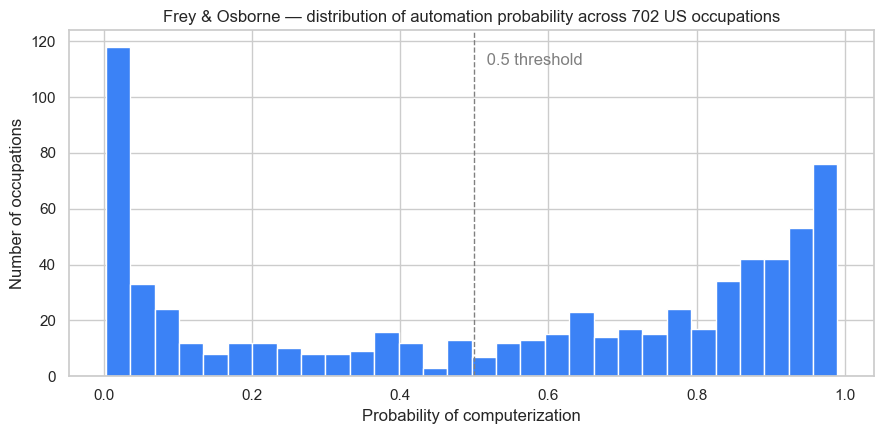

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(fo[prob_col], bins=30, edgecolor="white", color="#3b82f6")
ax.set_xlabel("Probability of computerization")
ax.set_ylabel("Number of occupations")
ax.set_title("Frey & Osborne — distribution of automation probability across 702 US occupations")
ax.axvline(0.5, color="grey", linestyle="--", linewidth=1)
ax.text(0.51, ax.get_ylim()[1] * 0.9, " 0.5 threshold", color="grey")
plt.tight_layout()
plt.show()

# Notice the bimodal-ish shape: occupations cluster at "very safe" or "very exposed",
# with relatively few in the middle. This is an artifact of the GP classifier and
# is part of why F&O has been criticized as too coarse.

**F&O takeaway for Module 2**

✅ Easy to ship. Single CSV, one join key (SOC code → occupation).  
✅ Universally recognized.  
⚠️  US-calibrated. The same occupation in Ghana may have very different task content
   (e.g., a "cashier" in the US is mostly POS scanning; in informal markets it's
   negotiation, mental arithmetic, customer relationship management).  
⚠️  Bimodal distribution — the model is overconfident at the extremes.  
⚠️  Pre-LLM. Built in 2013; the risk profile of cognitive non-routine work has
   shifted dramatically since.

**Honest use:** show F&O as a baseline, then *adjust it down or sideways* using
ILO task content + ITU connectivity. The "F&O recalibrated for LMIC context"
narrative is a strong submission angle.

---

## 2 · ILO Future of Work — task content indices

**Reality check:** There is **no single ILO CSV** called "task content indices."
The phrase refers to a body of academic work that derives task-level
exposure measures from survey microdata (PIAAC + STEP), generally following
Autor-Levy-Murnane (2003) task categories:

- **Routine cognitive** (e.g., calculations, record-keeping)
- **Routine manual** (e.g., assembly line)
- **Non-routine cognitive analytical** (e.g., problem solving)
- **Non-routine cognitive interpersonal** (e.g., negotiation, teaching)
- **Non-routine manual physical** (e.g., truck driving, plumbing)

Key references:

- **Lo Bello, Sanchez Puerta & Winkler (2019)** — *The Skill Content of Jobs and Economic Development.* World Bank Jobs Working Paper #23. Builds task indices for 30 countries using STEP + PIAAC.
- **Lewandowski et al. (2020)** — *The Global Distribution of Routine and Non-Routine Work.* IZA DP 13384. Predicts task content for ~85 countries via regression imputation.

What we *can* easily fetch from ILOSTAT today is **employment by occupation
(ISCO-08)** for any country. That gives you the denominator (how many people
are in each occupation); you'd then attach task scores to those occupations
using one of the academic datasets above (or, as a hack, by mapping ISCO →
SOC and reusing F&O / O\*NET task scores).

Below: pull employment-by-occupation for three LMICs to show the structure.

In [5]:
"""
Pull ILOSTAT 'Employment by sex and occupation' (ISCO-08, 1-digit) for a
handful of LMICs via ILOSTAT's SDMX-CSV REST endpoint.

Indicator: EMP_TEMP_SEX_OCU_NB — Employment by sex and occupation (thousands)
Docs: https://ilostat.ilo.org/data/bulk/

We use the SDMX 2.1 'data' endpoint with format=csv. Country codes are ISO-3.
"""

ILO_SDMX_BASE = "https://sdmx.ilo.org/rest/data/ILO,DF_EMP_TEMP_SEX_OCU_NB,1.0/"

# Three LMICs from very different regions
COUNTRIES = ["GHA", "VNM", "BOL"]  # Ghana, Vietnam, Bolivia

frames = []
for iso3 in COUNTRIES:
    # Key structure: .COUNTRY.SEX.CLASSIFICATION.....   (dots = wildcards)
    # We ask for all sexes (SEX_T = total), all ISCO-08 1-digit occupations.
    key = f"{iso3}.....A"  # frequency=Annual at the end; rest are wildcards
    url = (
        f"{ILO_SDMX_BASE}{key}"
        "?format=csv&startPeriod=2018&endPeriod=2023&detail=dataonly"
    )
    fname = f"ilo_emp_occ_{iso3}.csv"
    try:
        path = cached_download(url, fname)
        df = pd.read_csv(path)
        df["ref_country"] = iso3
        frames.append(df)
    except Exception as e:  # noqa: BLE001
        print(f"[skip] {iso3}: {e}")

if frames:
    ilo = pd.concat(frames, ignore_index=True)
    print(f"\nTotal rows: {len(ilo):,}")
    print(f"Columns: {list(ilo.columns)}")
    ilo.head(8)
else:
    print("No ILO data fetched. The SDMX endpoint format changes occasionally;")
    print("try the bulk download UI at https://ilostat.ilo.org/data/bulk/")
    ilo = pd.DataFrame()
ilo.head() if not ilo.empty else None

[cache] ilo_emp_occ_GHA.csv (52.8 KB)
[cache] ilo_emp_occ_VNM.csv (144.3 KB)
[cache] ilo_emp_occ_BOL.csv (215.4 KB)

Total rows: 4,335
Columns: ['DATAFLOW', 'REF_AREA', 'FREQ', 'MEASURE', 'SEX', 'OCU', 'TIME_PERIOD', 'OBS_VALUE', 'OBS_STATUS', 'UNIT_MEASURE_TYPE', 'UNIT_MEASURE', 'UNIT_MULT', 'SOURCE', 'NOTE_SOURCE', 'NOTE_INDICATOR', 'NOTE_CLASSIF', 'DECIMALS', 'UPPER_BOUND', 'LOWER_BOUND', 'ref_country']


,DATAFLOW,REF_AREA,FREQ,MEASURE,SEX,OCU,TIME_PERIOD,OBS_VALUE,OBS_STATUS,UNIT_MEASURE_TYPE,UNIT_MEASURE,UNIT_MULT,SOURCE,NOTE_SOURCE,NOTE_INDICATOR,NOTE_CLASSIF,DECIMALS,UPPER_BOUND,LOWER_BOUND,ref_country
0,ILO:DF_EMP_TEMP_SEX_OCU_NB(1.0),GHA,Q,EMP_TEMP_NB,SEX_T,OCU_SKILL_TOTAL,2022-Q1,11651.319,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GHA
1,ILO:DF_EMP_TEMP_SEX_OCU_NB(1.0),GHA,Q,EMP_TEMP_NB,SEX_T,OCU_SKILL_L3-4,2022-Q1,1048.371,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GHA
2,ILO:DF_EMP_TEMP_SEX_OCU_NB(1.0),GHA,Q,EMP_TEMP_NB,SEX_T,OCU_SKILL_L2,2022-Q1,8699.165,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GHA
3,ILO:DF_EMP_TEMP_SEX_OCU_NB(1.0),GHA,Q,EMP_TEMP_NB,SEX_T,OCU_SKILL_L1,2022-Q1,774.828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GHA
4,ILO:DF_EMP_TEMP_SEX_OCU_NB(1.0),GHA,Q,EMP_TEMP_NB,SEX_T,OCU_SKILL_X,2022-Q1,1128.955,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GHA


Illustrative ISCO-08 1-digit task content (placeholder values):
isco_1d                                     title  nr_cognitive  nr_interpersonal  routine  nr_manual
      1                                  Managers          0.65              0.78     0.40       0.20
      2                             Professionals          0.85              0.62     0.30       0.15
      3   Technicians and associate professionals          0.62              0.50     0.55       0.40
      4                  Clerical support workers          0.45              0.40     0.78       0.20
      5                 Service and sales workers          0.35              0.65     0.60       0.55
      6 Skilled agricultural / forestry / fishery          0.30              0.30     0.50       0.85
      7                  Craft and related trades          0.42              0.35     0.62       0.80
      8               Plant and machine operators          0.30              0.25     0.85       0.60
      9           

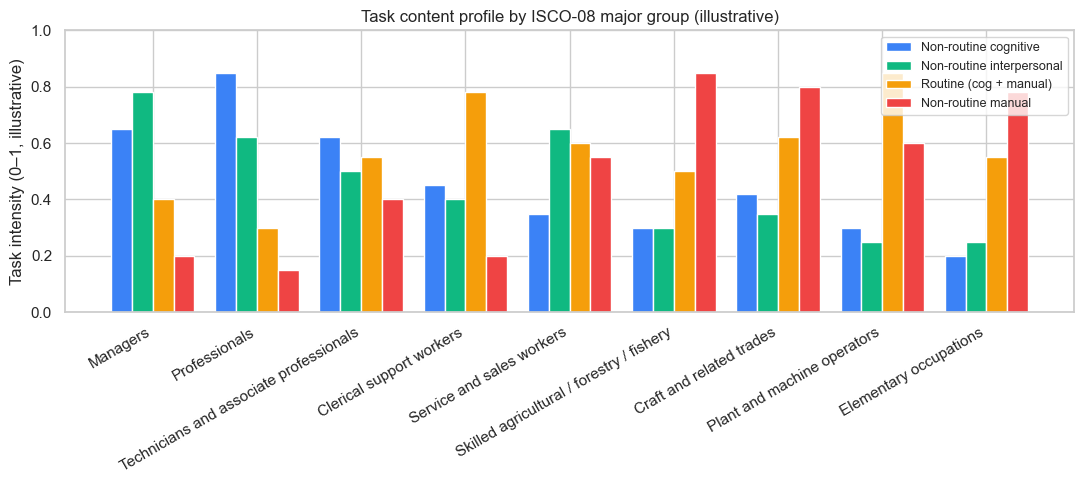

In [6]:
"""
Conceptual demo: how task content indices attach to occupations.

We have no live ILO task index file. Instead, we'll build a small illustrative
table using *published* Lewandowski et al. (2020) average task content scores
by ISCO-08 1-digit major group. These are stylized values from the literature
to illustrate structure — replace with the actual dataset before publishing.

Sources for actual values:
  - Lewandowski, Park, Hardy, Du (2020) IZA DP 13384, supplementary tables
  - Lo Bello, Sanchez Puerta, Winkler (2019) WB Jobs WP 23, appendix
"""

# Illustrative averages (NOT to be cited — placeholder values for demonstration)
TASK_INDEX_DEMO = pd.DataFrame(
    [
        # ISCO  Title                                        NRcog  NRintp  Routine  NRmanual
        ("1",   "Managers",                                   0.65,  0.78,  0.40,    0.20),
        ("2",   "Professionals",                              0.85,  0.62,  0.30,    0.15),
        ("3",   "Technicians and associate professionals",    0.62,  0.50,  0.55,    0.40),
        ("4",   "Clerical support workers",                   0.45,  0.40,  0.78,    0.20),
        ("5",   "Service and sales workers",                  0.35,  0.65,  0.60,    0.55),
        ("6",   "Skilled agricultural / forestry / fishery",  0.30,  0.30,  0.50,    0.85),
        ("7",   "Craft and related trades",                   0.42,  0.35,  0.62,    0.80),
        ("8",   "Plant and machine operators",                0.30,  0.25,  0.85,    0.60),
        ("9",   "Elementary occupations",                     0.20,  0.25,  0.55,    0.78),
    ],
    columns=["isco_1d", "title", "nr_cognitive", "nr_interpersonal",
             "routine", "nr_manual"],
)
print("Illustrative ISCO-08 1-digit task content (placeholder values):")
print(TASK_INDEX_DEMO.to_string(index=False))

# Plot the four task dimensions across major groups
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(TASK_INDEX_DEMO))
width = 0.2
for i, (col, label, color) in enumerate([
    ("nr_cognitive",     "Non-routine cognitive",      "#3b82f6"),
    ("nr_interpersonal", "Non-routine interpersonal",  "#10b981"),
    ("routine",          "Routine (cog + manual)",     "#f59e0b"),
    ("nr_manual",        "Non-routine manual",         "#ef4444"),
]):
    ax.bar(x + (i - 1.5) * width, TASK_INDEX_DEMO[col], width, label=label, color=color)
ax.set_xticks(x)
ax.set_xticklabels(TASK_INDEX_DEMO["title"], rotation=30, ha="right")
ax.set_ylabel("Task intensity (0–1, illustrative)")
ax.set_title("Task content profile by ISCO-08 major group (illustrative)")
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

**ILO task indices takeaway for Module 2**

✅ Task-level granularity beats occupation-level — closer to real automation mechanisms.  
✅ Multi-country (Lewandowski covers ~85 countries; Lo Bello ~30).  
✅ "Routine vs non-routine" framing maps cleanly onto modern AI/LLM displacement.  
⚠️  No clean public CSV — you have to download paper supplements or rebuild from STEP/PIAAC.  
⚠️  Less name recognition than F&O — you'll need to explain the methodology.  
⚠️  Country coverage of the *direct-measurement* version (Lo Bello) is limited to STEP/PIAAC countries.

**Honest use:** if you can spend ~half a day pulling Lewandowski's
supplementary tables and joining them onto ISCO codes, this becomes the
single most defensible signal for an LMIC-focused submission. Pair with
ILOSTAT employment shares to weight risk by actual workforce composition.

---

## 3 · World Bank STEP — Skills Toward Employment & Productivity

**What's in it:** Household and employer surveys directly measuring
**cognitive** (literacy, numeracy, problem-solving), **socioemotional** (Big-5,
grit, hostile attribution), and **job-relevant technical** skills, plus
labor market outcomes.

**Coverage:** ~17 LMIC studies across 4 waves, 2012–2017:

> Albania, Armenia, Azerbaijan, Bolivia, Bosnia & Herzegovina, Colombia,
> Georgia, Ghana, Kenya, Kosovo, Lao PDR, Macedonia, Serbia, Sri Lanka,
> Ukraine, Vietnam, Yunnan (China)

**Granularity:** individual (microdata) — thousands of respondents per country.

**Access:** No API. Microdata is at the **World Bank Microdata Library**
(`microdata.worldbank.org/catalog/step`) and requires a one-time registration
+ data use agreement per study. Files arrive as Stata `.dta` or SPSS.

**Why we care for Module 2:** STEP is the only dataset that lets you say
*"in Ghana specifically, workers in informal retail score X on numeracy and
Y on problem-solving."* That's the foundation for honest LMIC calibration of
both skills profiles (Module 1) and risk exposure (Module 2).

Below: pull the public catalog metadata to enumerate studies and surface
what variables each one carries.

In [7]:
"""
Pull the STEP catalog index from the Microdata Library's NADA-API.

The WB Microdata Library exposes catalog metadata (NOT microdata) via:
    https://microdata.worldbank.org/index.php/api/catalog/search?collection=step

That returns a JSON list of all studies in the STEP collection — useful for
showing scope, country/wave coverage, and pointing users to the registration
flow for actual microdata.
"""

STEP_CATALOG_URL = (
    "https://microdata.worldbank.org/index.php/api/catalog/search"
    "?collection=step&format=json&ps=100"
)

try:
    path = cached_download(STEP_CATALOG_URL, "step_catalog.json")
    catalog = json.loads(path.read_text())
    rows = catalog.get("result", {}).get("rows", [])
    print(f"Studies in STEP collection: {len(rows)}\n")

    if rows:
        step_idx = pd.DataFrame([
            {
                "id":         r.get("id"),
                "country":    r.get("nation"),
                "title":      r.get("title"),
                "year_start": r.get("year_start"),
                "year_end":   r.get("year_end"),
                "url":        r.get("url"),
            }
            for r in rows
        ]).sort_values(["country", "year_start"]).reset_index(drop=True)
        print(step_idx[["country", "year_start", "title"]].to_string(index=False))
    else:
        print("Catalog returned no rows — check the API endpoint shape.")
        step_idx = pd.DataFrame()
except Exception as e:  # noqa: BLE001
    print(f"[skip] STEP catalog fetch failed: {e}")
    print("Manual browse: https://microdata.worldbank.org/index.php/catalog/step")
    step_idx = pd.DataFrame()

[cache] step_catalog.json (12.9 KB)
Studies in STEP collection: 22

           country  year_start                                                                   title
           Albania        2017                   STEP Skills Measurement Employer Survey 2017 (Wave 4)
           Armenia        2013                   STEP Skills Measurement Employer Survey 2013 (Wave 2)
           Armenia        2013                  STEP Skills Measurement Household Survey 2013 (Wave 2)
        Azerbaijan        2013              STEP Skills Measurement Employer Survey 2013-2014 (Wave 1)
           Bolivia        2012                  STEP Skills Measurement Household Survey 2012 (Wave 1)
Bosnia-Herzegovina        2016              STEP Skills Measurement Employer Survey 2016-2017 (Wave 3)
             China        2012 STEP Skills Measurement Household Survey 2012 (Wave 1), Yunnan Province
          Colombia        2012                  STEP Skills Measurement Household Survey 2012 (Wave 1)
     

STEP studies by country × survey year:
year                2011  2012  2013  2015  2016  2017
country                                               
Albania                0     0     0     0     0     1
Armenia                0     0     2     0     0     0
Azerbaijan             0     0     1     0     0     0
Bolivia                0     1     0     0     0     0
Bosnia-Herzegovina     0     0     0     0     1     0
China                  0     1     0     0     0     0
Colombia               0     1     0     0     0     0
Georgia                0     1     1     0     0     0
Ghana                  0     0     1     0     0     0
Kenya                  0     0     1     0     1     0
Kosovo                 0     0     0     1     0     0
Lao PDR                0     1     0     0     0     0
Macedonia, FYR         0     0     1     0     0     0
Philippines            0     0     0     1     0     0
Serbia                 0     0     0     1     0     0
Sri Lanka              0  

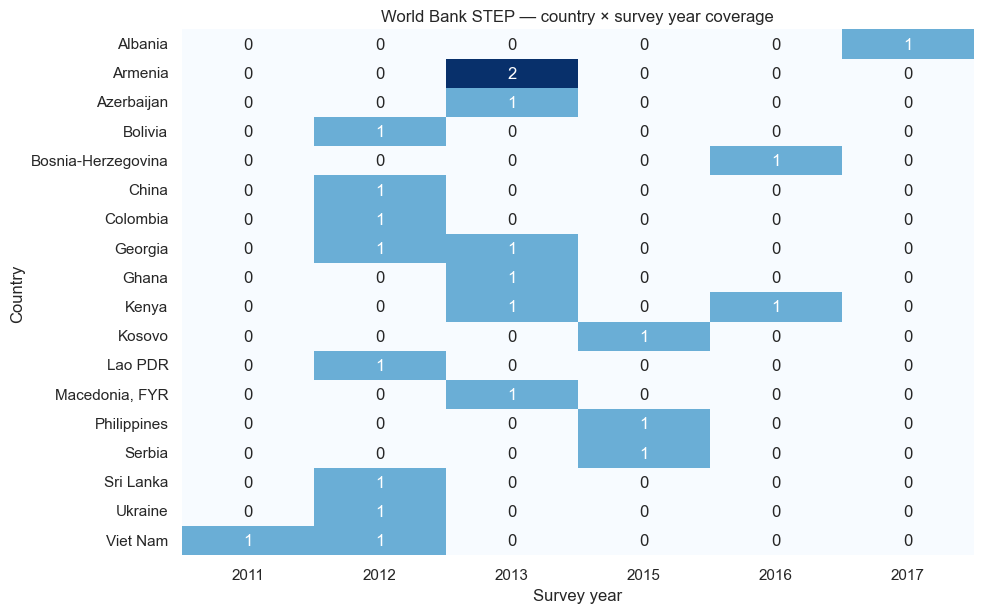

In [8]:
"""
Coverage view: countries × wave years.
"""
if not step_idx.empty:
    coverage = (
        step_idx.assign(year=step_idx["year_start"])
        .groupby(["country", "year"])
        .size()
        .unstack(fill_value=0)
    )
    print("STEP studies by country × survey year:")
    print(coverage.to_string())

    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(coverage))))
    sns.heatmap(coverage, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title("World Bank STEP — country × survey year coverage")
    ax.set_xlabel("Survey year")
    ax.set_ylabel("Country")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping coverage chart — catalog not loaded.")

**STEP takeaway for Module 2**

✅ Only LMIC-native skill measurement dataset of its kind.  
✅ Covers cognitive + socioemotional + technical → matches the "skills profile" framing of Module 1 directly.  
⚠️  Microdata only — no aggregate API. Per-study download + DUA acceptance.  
⚠️  Frozen at 2017 (no recent waves). For 2026, treat as ground-truth-baseline,
   not real-time signal.  
⚠️  Country list is small (~17). Not a global dataset.

**Honest use for a hackathon:** download 1–2 STEP country files (Ghana is a
natural fit given Amara's persona) and use them to derive **realistic prior
distributions** for skill levels and task content in your Module 1 profile
generator. Don't try to use STEP as a live lookup.

**Registration workflow:** create an account at
[microdata.worldbank.org](https://microdata.worldbank.org), open the study
page (e.g., `/index.php/catalog/2010` for Ghana STEP 2013), click "Get
Microdata", agree to terms, download `.dta`, then `pd.read_stata(...)`.

---

## 4 · ITU Digital Development — connectivity context

**What's in it:** Country-year time series for ICT indicators, including:

- Individuals using the Internet (% of population) — indicator id `11624`
- Active mobile-broadband subscriptions per 100 inhabitants — id `11632`
- Fixed-broadband subscriptions per 100 inhabitants — id `19303`
- Households with Internet access at home — id `12047`

**Coverage:** ~200 economies, annual, typically 2000 → present.

**Access:** ITU **DataHub** REST endpoint:
`https://api.datahub.itu.int/v2/data/download/byid/{INDICATOR_ID}/iscollection/false`

**Why we care for Module 2:** AI displacement isn't just about whether a task
*can* be automated — it's about whether the local economy has the
infrastructure to deploy that automation. A country at 15% mobile-broadband
penetration sees fundamentally different displacement dynamics than one at
85%. ITU data lets you scale risk by realistic deployment ceilings.

Below: pull internet penetration + mobile broadband for a basket of LMICs.

In [9]:
"""
Pull two connectivity indicators.

Primary path: ITU DataHub 'byid' endpoint
    https://api.datahub.itu.int/v2/data/download/byid/{id}/iscollection/false
    11624 — Individuals using the Internet (%)
    11632 — Active mobile-broadband subscriptions per 100 inhabitants

Fallback: World Bank WDI API (mirrors most ITU indicators, very reliable)
    IT.NET.USER.ZS  — Individuals using the Internet (% of population)
    IT.CEL.SETS.P2  — Mobile cellular subscriptions (per 100 people)
"""

ITU_BYID = "https://api.datahub.itu.int/v2/data/download/byid/{id}/iscollection/false"
ITU_INDICATORS = {
    11624: "internet_users_pct",
    11632: "mobile_bband_per_100",
}

WDI_FALLBACKS = {
    "internet_users_pct":  "IT.NET.USER.ZS",
    "mobile_bband_per_100": "IT.CEL.SETS.P2",  # mobile cellular as proxy
}


def fetch_wdi(indicator: str) -> pd.DataFrame:
    """Fetch a WDI indicator as a tidy DataFrame across all countries."""
    url = (
        f"https://api.worldbank.org/v2/country/all/indicator/{indicator}"
        "?format=json&per_page=20000"
    )
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    payload = r.json()
    # WDI returns [meta, rows]
    rows = payload[1] if len(payload) > 1 else []
    return pd.DataFrame([
        {
            "iso3":  row["countryiso3code"],
            "country": row["country"]["value"],
            "year":  int(row["date"]),
            "value": row["value"],
        }
        for row in rows
        if row.get("value") is not None
    ])


itu_frames: dict[str, pd.DataFrame] = {}
for ind_id, short in ITU_INDICATORS.items():
    url = ITU_BYID.format(id=ind_id)
    fname = f"itu_{short}_{ind_id}.csv"
    try:
        path = cached_download(url, fname)
        df = pd.read_csv(path, encoding="utf-8-sig")
        df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
        itu_frames[short] = df
        print(f"[itu OK] {short}: shape={df.shape}, cols={list(df.columns)[:6]}")
    except Exception as e:  # noqa: BLE001
        print(f"[itu fail] {short}: {e} → trying WDI fallback")
        try:
            wdi = fetch_wdi(WDI_FALLBACKS[short])
            wdi_path = DATA_DIR / f"wdi_{short}.csv"
            wdi.to_csv(wdi_path, index=False)
            itu_frames[short] = wdi
            print(f"[wdi OK ] {short}: shape={wdi.shape}")
        except Exception as e2:  # noqa: BLE001
            print(f"[wdi fail] {short}: {e2}")

print("\nLoaded connectivity indicators:", list(itu_frames.keys()))
if itu_frames:
    sample_key = next(iter(itu_frames))
    print(f"\nSample ({sample_key}):")
    print(itu_frames[sample_key].head(3))

[cache] itu_internet_users_pct_11624.csv (81.7 KB)
[itu fail] internet_users_pct: 'utf-8' codec can't decode byte 0xaa in position 10: invalid start byte → trying WDI fallback
[wdi OK ] internet_users_pct: shape=(6917, 4)
[cache] itu_mobile_bband_per_100_11632.csv (101.8 KB)
[itu fail] mobile_bband_per_100: 'utf-8' codec can't decode byte 0xab in position 10: invalid start byte → trying WDI fallback
[wdi OK ] mobile_bband_per_100: shape=(13071, 4)

Loaded connectivity indicators: ['internet_users_pct', 'mobile_bband_per_100']

Sample (internet_users_pct):
  iso3                      country  year  value
0  AFE  Africa Eastern and Southern  2025   30.4
1  AFE  Africa Eastern and Southern  2024   28.8
2  AFE  Africa Eastern and Southern  2023   27.8


Using cols: iso='iso3', year='year', value='value'


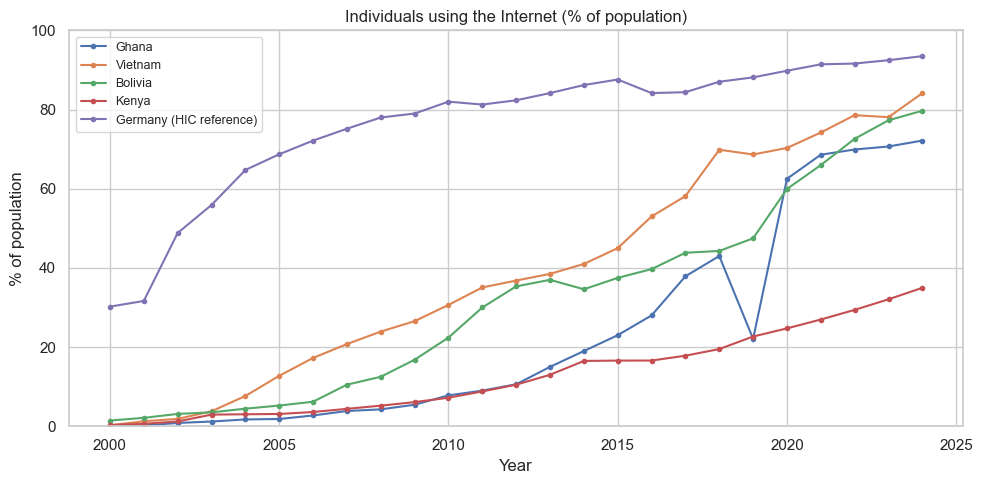


Latest internet-penetration snapshot:
                country  year     value
Germany (HIC reference)  2024 93.499996
                  Kenya  2024 34.976225
                Vietnam  2024 84.150000
                  Ghana  2024 72.175697
                Bolivia  2024 79.704697


In [10]:
"""
Plot internet penetration over time for a basket of LMICs vs a high-income
reference. AI displacement risk is not uniformly distributed in time —
connectivity gaps gate when displacement actually arrives.

Auto-detects column names because ITU and WDI use slightly different schemas.
"""

PEER_COUNTRIES = {
    "GHA": "Ghana",
    "VNM": "Vietnam",
    "BOL": "Bolivia",
    "KEN": "Kenya",
    "DEU": "Germany (HIC reference)",
}

if "internet_users_pct" in itu_frames:
    iu = itu_frames["internet_users_pct"].copy()

    iso_col   = next((c for c in iu.columns if c == "iso3" or "iso" in c), None)
    year_col  = next((c for c in iu.columns if c == "year" or "time" in c), None)
    value_col = next((c for c in iu.columns if c in ("value", "obs_value")), None)

    print(f"Using cols: iso={iso_col!r}, year={year_col!r}, value={value_col!r}")

    if all([iso_col, year_col, value_col]):
        sub = iu[iu[iso_col].isin(PEER_COUNTRIES.keys())].copy()
        sub[year_col]  = pd.to_numeric(sub[year_col], errors="coerce")
        sub[value_col] = pd.to_numeric(sub[value_col], errors="coerce")
        sub = sub.dropna(subset=[year_col, value_col])
        sub = sub[sub[year_col] >= 2000]

        fig, ax = plt.subplots(figsize=(10, 5))
        for iso3, label in PEER_COUNTRIES.items():
            d = sub[sub[iso_col] == iso3].sort_values(year_col)
            if len(d):
                ax.plot(d[year_col], d[value_col], marker="o", markersize=3, label=label)
        ax.set_title("Individuals using the Internet (% of population)")
        ax.set_xlabel("Year")
        ax.set_ylabel("% of population")
        ax.set_ylim(0, 100)
        ax.legend(loc="upper left", fontsize=9)
        plt.tight_layout()
        plt.show()

        # Quick takeaway: snapshot of latest year per country
        latest = (
            sub.sort_values(year_col)
            .groupby(iso_col)
            .tail(1)[[iso_col, year_col, value_col]]
        )
        latest = latest[latest[iso_col].isin(PEER_COUNTRIES)]
        latest["country"] = latest[iso_col].map(PEER_COUNTRIES)
        print("\nLatest internet-penetration snapshot:")
        print(latest[["country", year_col, value_col]].to_string(index=False))
    else:
        print("Could not auto-detect columns. Inspect itu_frames['internet_users_pct'].head().")
else:
    print("No internet_users_pct loaded — both ITU and WDI fallback failed.")

**ITU takeaway for Module 2**

✅ Clean public REST API. Country-year panel. ~25 years of history.  
✅ Universal coverage (~200 economies).  
✅ Lets you make the "AI risk gated by infrastructure" argument with a real
   chart instead of a slide bullet.  
⚠️  It's *context*, not direct skills/automation data. Use it as a multiplier
   on F&O / ILO risk, not as a primary signal.  
⚠️  Lag of 1–2 years on most indicators.

**Honest use:** wrap your automation risk score in a connectivity adjustment:
`adjusted_risk = base_risk × f(internet_penetration, mobile_bband)`. That's a
3-line function that turns a generic risk score into a locally-honest one.

---

## Synthesis — what stack to build Module 2 on

Going by what we've actually seen above:

| Dataset | Use it as | Implementation cost | Submission strength |
|---|---|---|---|
| **Frey & Osborne** | Baseline risk score (then critiqued) | Trivial — single CSV | ★★★ recognition, ★ LMIC honesty |
| **ILO task indices** (Lewandowski) | Primary risk signal, LMIC-honest | Medium — paper supplement munging | ★★★★ defensibility |
| **STEP** | Calibration prior on what LMIC workers actually do | High — registration + Stata munging | ★★★★ ground truth, narrow countries |
| **ITU Digital Development** | Connectivity multiplier on risk | Trivial — REST API | ★★★ adds local realism cheaply |

### Recommended minimum stack for a hackathon

1. **Frey & Osborne** as a baseline (1 hour to wire)
2. **ITU internet penetration** as a connectivity multiplier (1 hour)
3. **One STEP country file** (Ghana) as a ground-truth case study for the
   demo narrative (half a day if you're fast)

That's enough to satisfy the "≥1 real automation exposure dataset" requirement
*and* tell an LMIC-honest story.

### If you have more time

Add **Lewandowski task indices** as the primary risk signal and demote F&O to
a comparison baseline. That single change moves your submission from
"recognizable" to "defensible to a World Bank judge."

### Don't bother with

Trying to use STEP microdata as a live lookup in the running app — too heavy
for a 48-hour build, and the country coverage is too narrow. Use it
offline to derive priors / calibration constants that you bake in.